<a href="https://colab.research.google.com/github/rafi1624/PCVK_18_Rafi-Abyantara/blob/main/Week%2002/Week%2002-Tugas%20Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!wget -O sample.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

--2026-09-10 16:45:26--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91814 (90K) [image/jpeg]
Saving to: ‘sample.jpg’

sample.jpg          100%[===================>]  89.66K  --.-KB/s    in 0.01s   

2026-09-10 16:45:27 (7.20 MB/s) - ‘sample.jpg’ saved [91814/91814]



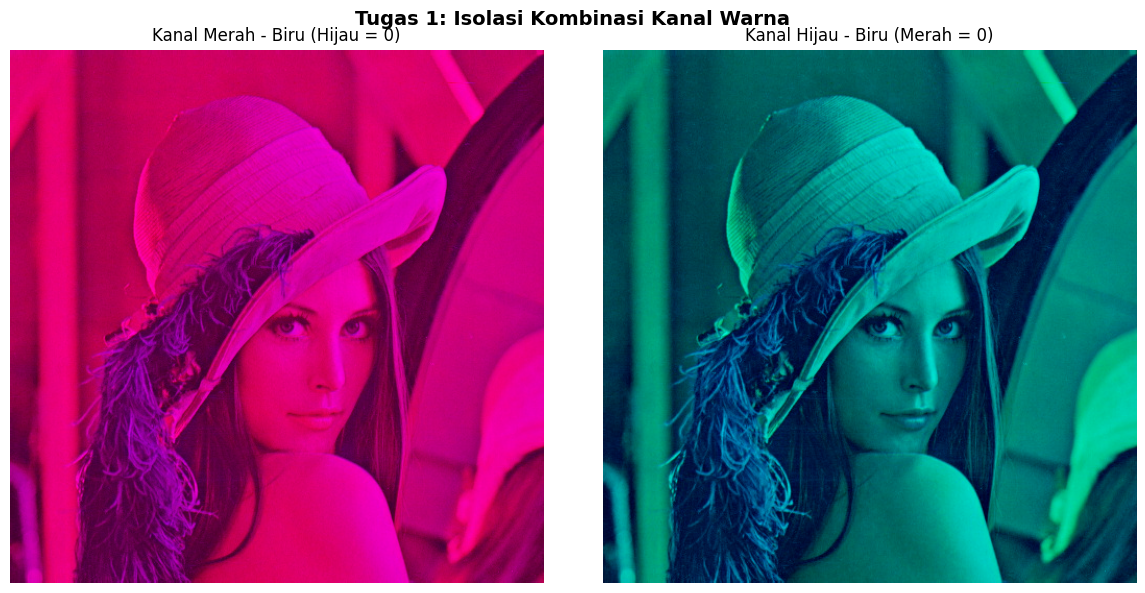

In [3]:
import cv2
import matplotlib.pyplot as plt

# 1. Baca citra dan ubah ke format RGB
img_bgr = cv2.imread('sample.jpg')

# Pengecekan keamanan
if img_bgr is None:
    raise FileNotFoundError("File 'sample.jpg' tidak ditemukan di direktori!")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 2. Kombinasi Kanal Merah-Biru (Kanal Hijau dinolkan)
img_red_blue = img_rgb.copy()
img_red_blue[:, :, 1] = 0  # Green = 0

# 3. Kombinasi Kanal Hijau-Biru (Kanal Merah dinolkan)
img_green_blue = img_rgb.copy()
img_green_blue[:, :, 0] = 0  # Red = 0

# 4. Tampilkan berdampingan dalam satu figure
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_red_blue)
plt.title("Kanal Merah - Biru (Hijau = 0)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_green_blue)
plt.title("Kanal Hijau - Biru (Merah = 0)")
plt.axis('off')

plt.suptitle("Tugas 1: Isolasi Kombinasi Kanal Warna", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

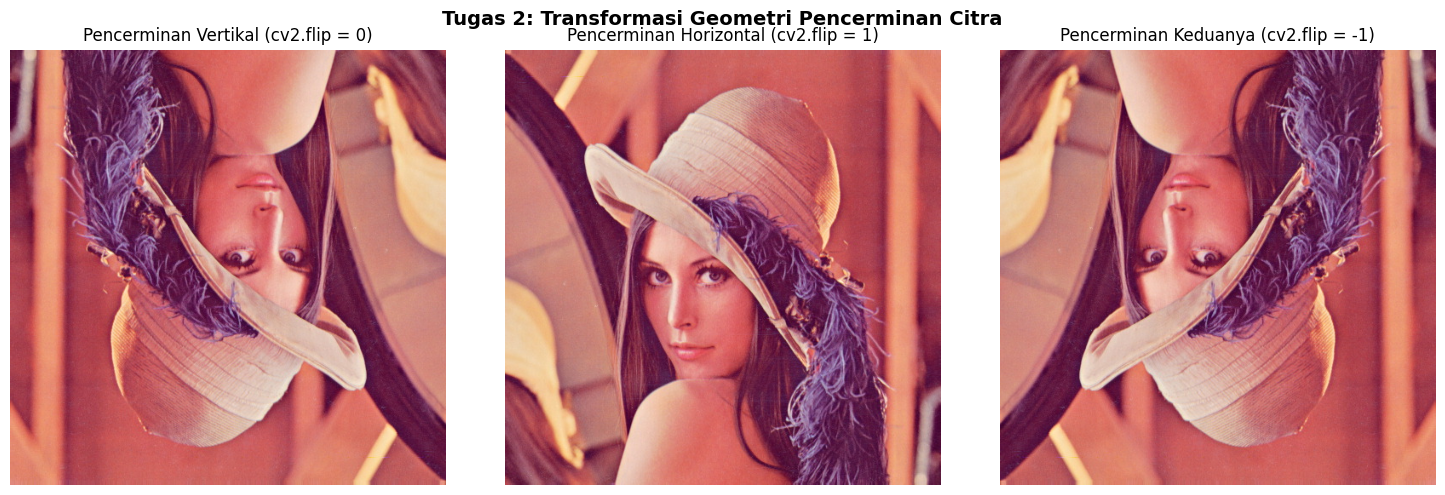

In [4]:
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread('sample.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 1. Lakukan transformasi pencerminan
flip_vertikal = cv2.flip(img_rgb, 0)
flip_horizontal = cv2.flip(img_rgb, 1)
flip_keduanya = cv2.flip(img_rgb, -1)

# 2. Tampilkan dalam satu figure dengan 3 subplot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(flip_vertikal)
plt.title("Pencerminan Vertikal (cv2.flip = 0)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(flip_horizontal)
plt.title("Pencerminan Horizontal (cv2.flip = 1)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flip_keduanya)
plt.title("Pencerminan Keduanya (cv2.flip = -1)")
plt.axis('off')

plt.suptitle("Tugas 2: Transformasi Geometri Pencerminan Citra", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Silakan upload foto aktivitas Anda:


Saving ktp.jpg to ktp.jpg
Foto berhasil dimuat! Dimensi: Tinggi=1783px, Lebar=2717px


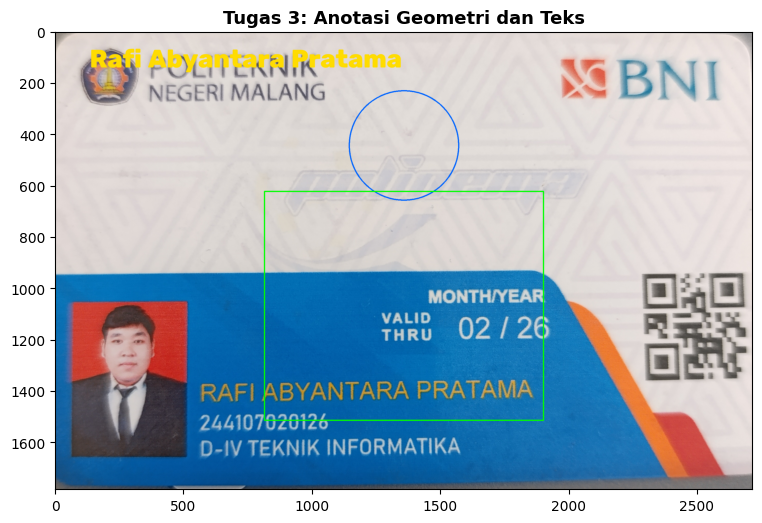

In [6]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# 1. Munculkan tombol upload untuk memilih foto aktivitas Anda
print("Silakan upload foto aktivitas Anda:")
uploaded = files.upload()

# Ambil nama file yang baru saja diupload
foto_path = list(uploaded.keys())[0]

# 2. Baca citra dan ubah ke RGB
img_bgr = cv2.imread(foto_path)
img_annotated = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

h, w, _ = img_annotated.shape
print(f"Foto berhasil dimuat! Dimensi: Tinggi={h}px, Lebar={w}px")

# 3. Anotasi: Kotak (Badan) & Lingkaran (Wajah)
# CATATAN: Sesuaikan angka koordinat berikut dengan letak tubuh/wajah di foto Anda
# Format koordinat: (x, y) di mana x = horizontal, y = vertikal

# Contoh estimasi proporsional berdasarkan ukuran gambar:
face_center = (int(w * 0.5), int(h * 0.25))  # Posisi tengah wajah (x, y)
face_radius = int(min(w, h) * 0.12)           # Radius lingkaran wajah

body_p1 = (int(w * 0.3), int(h * 0.35))      # Sudut kiri atas badan (x1, y1)
body_p2 = (int(w * 0.7), int(h * 0.85))      # Sudut kanan bawah badan (x2, y2)

# Gambar Lingkaran Wajah (Biru: RGB=(0, 100, 255))
cv2.circle(img_annotated, center=face_center, radius=face_radius, color=(0, 100, 255), thickness=3)

# Gambar Persegi Panjang Badan (Hijau: RGB=(0, 255, 0))
cv2.rectangle(img_annotated, pt1=body_p1, pt2=body_p2, color=(0, 255, 0), thickness=3)

# 4. Tambahkan Nama
nama = "Rafi Abyantara Pratama"
cv2.putText(
    img_annotated,
    text=nama,
    org=(int(w * 0.05), int(h * 0.08)),  # Letak teks di pojok kiri atas
    fontFace=cv2.FONT_HERSHEY_DUPLEX,
    fontScale=w / 800,                   # Skala font otomatis menyesuaikan lebar foto
    color=(255, 220, 0),                 # Warna kuning (RGB)
    thickness=2,
    lineType=cv2.LINE_AA
)

# 5. Tampilkan hasil
plt.figure(figsize=(9, 9))
plt.imshow(img_annotated)
plt.title("Tugas 3: Anotasi Geometri dan Teks", fontsize=13, fontweight='bold')
plt.axis('on')  # 'on' agar sumbu koordinat piksel terlihat untuk memudahkan koreksi posisi jika meleset
plt.show()

Dimensi Awal           : (512, 512)
Dimensi Downscale      : (128, 128)
Dimensi Upscale        : (512, 512)
--------------------------------------------------
Rata-rata Intensitas Asli       : 124.2006 | Std Dev: 47.9030
Rata-rata Intensitas Hasil Akhir: 124.0937 | Std Dev: 45.3097
Selisih Nilai Rata-rata         : 0.1069
Rata-rata Error Piksel (|Asli - Akhir|): 5.8643
Error Maksimum Satu Piksel      : 108
Mean Squared Error (MSE)        : 104.9860


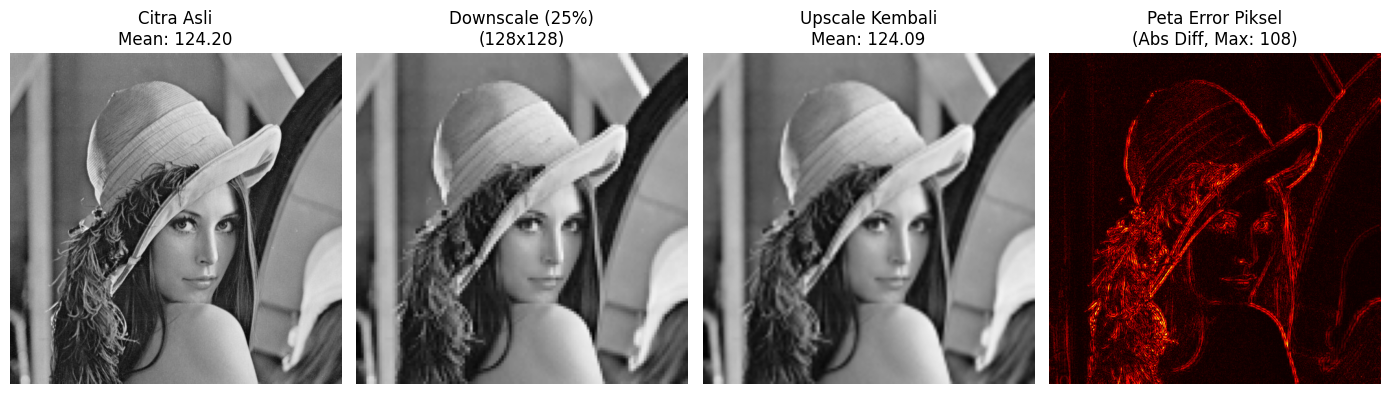

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Unduh atau muat citra input
!wget -q -O sample_analisis.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

# 2. Baca citra dalam mode Grayscale
img_original = cv2.imread('sample_analisis.jpg', cv2.IMREAD_GRAYSCALE)
h_orig, w_orig = img_original.shape

# 3. Downsampling: Perkecil citra menjadi 25% dari ukuran asli (faktor 0.25)
scale_down = 0.25
img_downscaled = cv2.resize(
    img_original,
    (int(w_orig * scale_down), int(h_orig * scale_down)),
    interpolation=cv2.INTER_AREA
)

# 4. Upsampling: Perbesar kembali ke dimensi awal (menggunakan interpolasi bilinear)
img_upscaled = cv2.resize(
    img_downscaled,
    (w_orig, h_orig),
    interpolation=cv2.INTER_LINEAR
)

# 5. Hitung selisih mutlak (Absolute Difference) antar citra
diff_img = cv2.absdiff(img_original, img_upscaled)

# 6. Kalkulasi metrik statistik numerik
mean_orig = float(np.mean(img_original))
std_orig = float(np.std(img_original))

mean_up = float(np.mean(img_upscaled))
std_up = float(np.std(img_upscaled))

mean_diff = float(np.mean(diff_img))
max_diff = int(np.max(diff_img))
mse = float(np.mean((img_original.astype("float") - img_upscaled.astype("float")) ** 2))

# 7. Cetak Data Hasil Numerik
print(f"Dimensi Awal           : {img_original.shape}")
print(f"Dimensi Downscale      : {img_downscaled.shape}")
print(f"Dimensi Upscale        : {img_upscaled.shape}")
print("-" * 50)
print(f"Rata-rata Intensitas Asli       : {mean_orig:.4f} | Std Dev: {std_orig:.4f}")
print(f"Rata-rata Intensitas Hasil Akhir: {mean_up:.4f} | Std Dev: {std_up:.4f}")
print(f"Selisih Nilai Rata-rata         : {abs(mean_orig - mean_up):.4f}")
print(f"Rata-rata Error Piksel (|Asli - Akhir|): {mean_diff:.4f}")
print(f"Error Maksimum Satu Piksel      : {max_diff}")
print(f"Mean Squared Error (MSE)        : {mse:.4f}")

# 8. Visualisasi Komparasi
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_original, cmap='gray')
plt.title(f"Citra Asli\nMean: {mean_orig:.2f}")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_downscaled, cmap='gray')
plt.title(f"Downscale (25%)\n({img_downscaled.shape[1]}x{img_downscaled.shape[0]})")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_upscaled, cmap='gray')
plt.title(f"Upscale Kembali\nMean: {mean_up:.2f}")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(diff_img, cmap='hot')
plt.title(f"Peta Error Piksel\n(Abs Diff, Max: {max_diff})")
plt.axis('off')

plt.tight_layout()
plt.show()

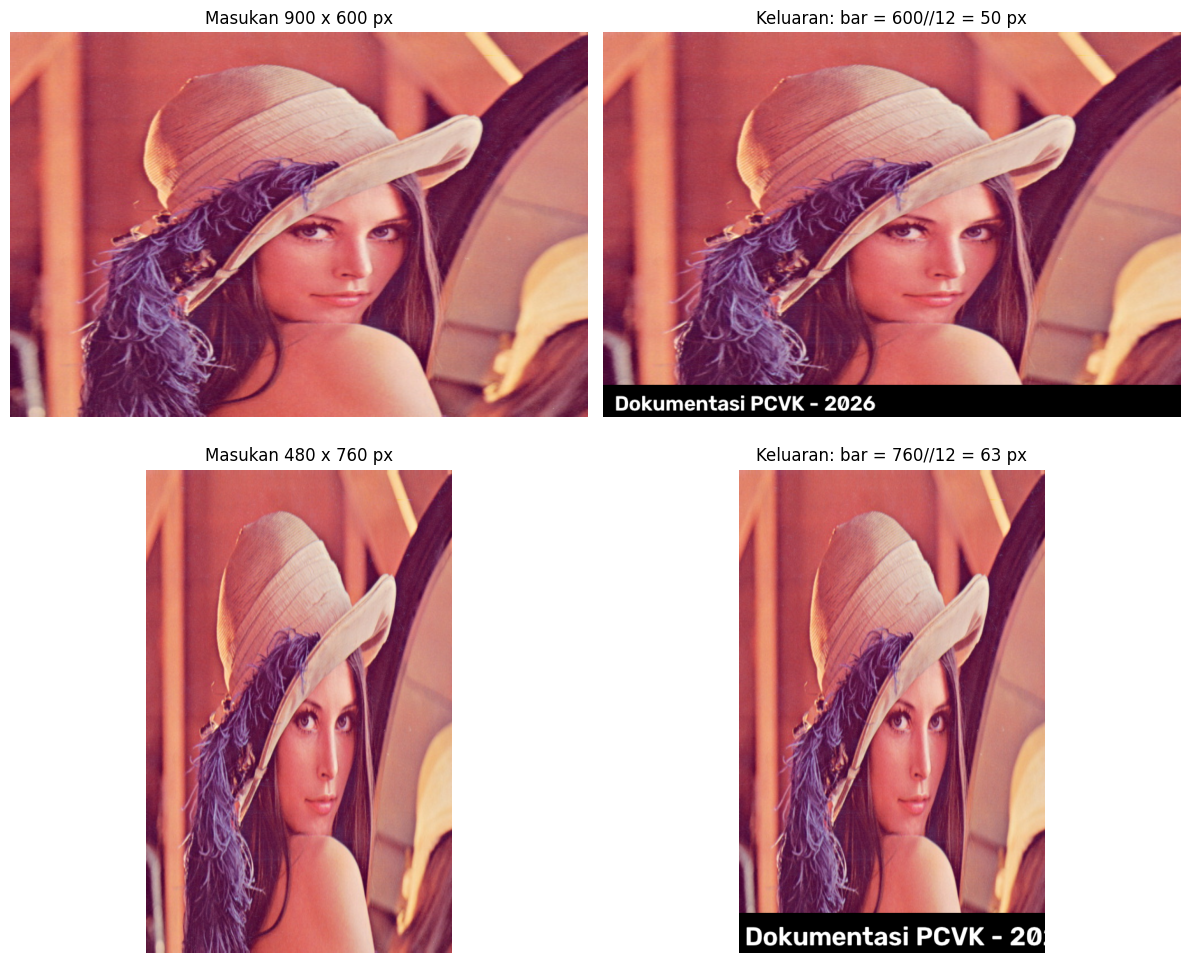

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def tambah_label_adaptif(citra, teks="Dokumentasi PCVK - 2026"):
    """
    Menambahkan label bar hitam dan teks di bagian bawah citra
    dengan ukuran dan proporsi yang adaptif terhadap dimensi citra.
    """
    hasil = citra.copy()
    h, w = hasil.shape[:2]

    # 1. Hitung tinggi bar secara proporsional sesuai acuan (Tinggi // 12)
    tinggi_bar = h // 12

    # 2. Buat bar hitam di bagian bawah menggunakan cv2.rectangle
    # Koordinat pt1: sudut kiri atas bar, pt2: sudut kanan bawah citra
    cv2.rectangle(hasil, (0, h - tinggi_bar), (w, h), (0, 0, 0), -1)

    # 3. Hitung skala font dan ketebalan garis secara adaptif terhadap tinggi bar
    font_face = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = tinggi_bar / 45.0
    thickness = max(1, int(tinggi_bar / 25))

    # 4. Tentukan posisi baseline teks agar berada di tengah vertikal bar
    (teks_w, teks_h), baseline = cv2.getTextSize(teks, font_face, font_scale, thickness)
    offset_x = int(w * 0.02)  # Margin kiri 2% dari lebar citra
    pos_y = h - (tinggi_bar - teks_h) // 2

    # 5. Bubuhkan teks berwarna putih (255, 255, 255)
    cv2.putText(
        hasil,
        teks,
        (offset_x, pos_y),
        font_face,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )

    return hasil, tinggi_bar

# ==========================================
# Pengujian pada Dua Citra Berbeda Ukuran
# ==========================================

# 1. Unduh citra sampel
!wget -q -O sample_dok.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
img_raw = cv2.imread('sample_dok.jpg')
img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

# 2. Buat Citra 1 (Landscape: 900 x 600 px) & Citra 2 (Portrait: 480 x 760 px)
img_1 = cv2.resize(img_rgb, (900, 600))
img_2 = cv2.resize(img_rgb, (480, 760))

# 3. Terapkan fungsi adaptif pada kedua citra
keluaran_1, bar_1 = tambah_label_adaptif(img_1)
keluaran_2, bar_2 = tambah_label_adaptif(img_2)

# 4. Tampilkan berdampingan sesuai format modul
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Baris 1: Citra Landscape
axs[0, 0].imshow(img_1)
axs[0, 0].set_title(f"Masukan {img_1.shape[1]} x {img_1.shape[0]} px")
axs[0, 0].axis('off')

axs[0, 1].imshow(keluaran_1)
axs[0, 1].set_title(f"Keluaran: bar = {img_1.shape[0]}//12 = {bar_1} px")
axs[0, 1].axis('off')

# Baris 2: Citra Portrait
axs[1, 0].imshow(img_2)
axs[1, 0].set_title(f"Masukan {img_2.shape[1]} x {img_2.shape[0]} px")
axs[1, 0].axis('off')

axs[1, 1].imshow(keluaran_2)
axs[1, 1].set_title(f"Keluaran: bar = {img_2.shape[0]}//12 = {bar_2} px")
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

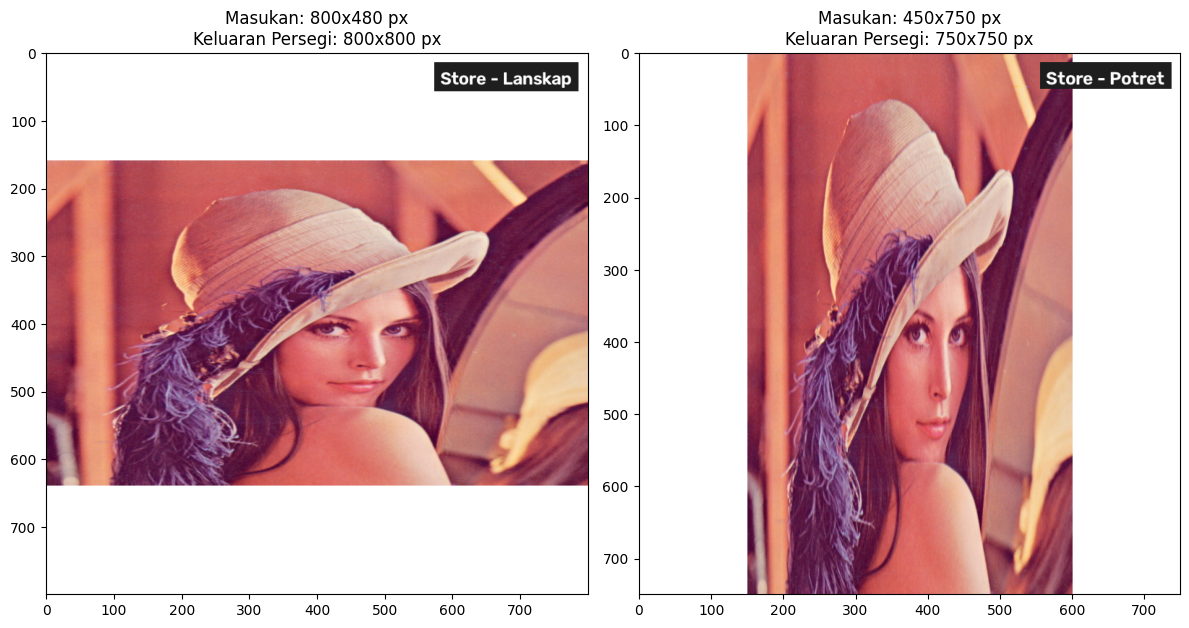

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def buat_thumbnail_persegi(citra, nama_toko="Official Store", warna_kanvas=(255, 255, 255)):
    """
    Mengubah citra berukuran apa pun menjadi rasio persegi (1:1) tanpa mengubah rasio aslinya.
    Sisa ruang diisi kanvas berwarna (letterboxing/pillarboxing) dan diberi watermark/logo adaptif.
    """
    h, w = citra.shape[:2]

    # 1. Tentukan ukuran sisi kanvas persegi berdasarkan dimensi terpanjang citra
    sisi = max(h, w)

    # 2. Buat kanvas persegi menggunakan NumPy (tipe data uint8)
    # Default: (255, 255, 255) untuk warna putih
    kanvas = np.full((sisi, sisi, 3), warna_kanvas, dtype=np.uint8)

    # 3. Hitung koordinat offset agar citra terpasang tepat di tengah kanvas
    y_offset = (sisi - h) // 2
    x_offset = (sisi - w) // 2

    # 4. Tempatkan citra ke tengah kanvas menggunakan pengirisan (slicing)
    kanvas[y_offset : y_offset + h, x_offset : x_offset + w] = citra

    # 5. Tambahkan logo / teks nama toko secara proporsional terhadap ukuran kanvas
    font_face = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = sisi / 900.0                       # Skala teks adaptif
    thickness = max(1, int(sisi / 350))             # Ketebalan adaptif

    # Hitung dimensi bounding box teks
    (tw, th), baseline = cv2.getTextSize(nama_toko, font_face, font_scale, thickness)

    # Posisi teks: pojok kanan atas dengan padding 3% dari ukuran kanvas
    pad = int(sisi * 0.03)
    teks_x = sisi - tw - pad
    teks_y = pad + th

    # Background badge semi-transparan/kontras di belakang teks agar selalu terbaca
    cv2.rectangle(
        kanvas,
        (teks_x - int(pad * 0.4), teks_y - th - int(pad * 0.4)),
        (teks_x + tw + int(pad * 0.4), teks_y + baseline + int(pad * 0.2)),
        (30, 30, 30),
        -1
    )

    # Teks nama toko (warna putih)
    cv2.putText(
        kanvas,
        nama_toko,
        (teks_x, teks_y),
        font_face,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )

    return kanvas

# ==========================================
# Pengujian pada Citra Lanskap & Citra Potret
# ==========================================

# Unduh citra sampel jika belum ada
!wget -q -O sample_case2.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
img_raw = cv2.imread('sample_case2.jpg')
img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

# 1. Buat sampel citra lanskap (800 x 480) dan citra potret (450 x 750)
img_lanskap = cv2.resize(img_rgb, (800, 480))
img_potret  = cv2.resize(img_rgb, (450, 750))

# 2. Terapkan fungsi pembuat thumbnail persegi
thumb_lanskap = buat_thumbnail_persegi(img_lanskap, nama_toko="Store - Lanskap")
thumb_potret  = buat_thumbnail_persegi(img_potret, nama_toko="Store - Potret")

# 3. Visualisasikan Hasil
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(thumb_lanskap)
plt.title(f"Masukan: {img_lanskap.shape[1]}x{img_lanskap.shape[0]} px\nKeluaran Persegi: {thumb_lanskap.shape[0]}x{thumb_lanskap.shape[1]} px")
plt.axis('on')  # 'on' agar rasio 1:1 dan margin pengisi (padding) terlihat jelas

plt.subplot(1, 2, 2)
plt.imshow(thumb_potret)
plt.title(f"Masukan: {img_potret.shape[1]}x{img_potret.shape[0]} px\nKeluaran Persegi: {thumb_potret.shape[0]}x{thumb_potret.shape[1]} px")
plt.axis('on')

plt.tight_layout()
plt.show()